# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 1. Scatter Plot : Poids vs Consommation (MPG)
Ce graphique montre la relation entre le poids du véhicule et sa consommation de carburant. On s'attend à une corrélation négative : plus le véhicule est lourd, moins il est économe en carburant.

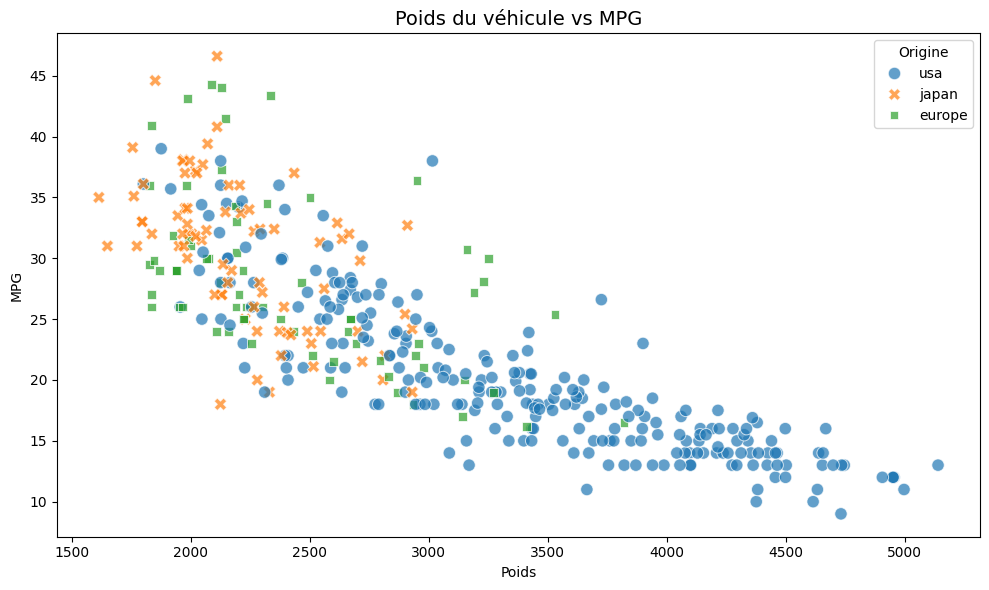

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mpg_df, x='weight', y='mpg', hue='origin', style='origin', s=80, alpha=0.7)
plt.title('Poids du véhicule vs MPG', fontsize=14)
plt.xlabel('Poids')
plt.ylabel('MPG')
plt.legend(title='Origine')
plt.tight_layout()
plt.show()

## 2. Scatter Plot : Puissance (Horsepower) vs Consommation (MPG)

Ce graphique explore la relation entre la puissance du moteur et la consommation. Les couleurs représentent le nombre de cylindres.

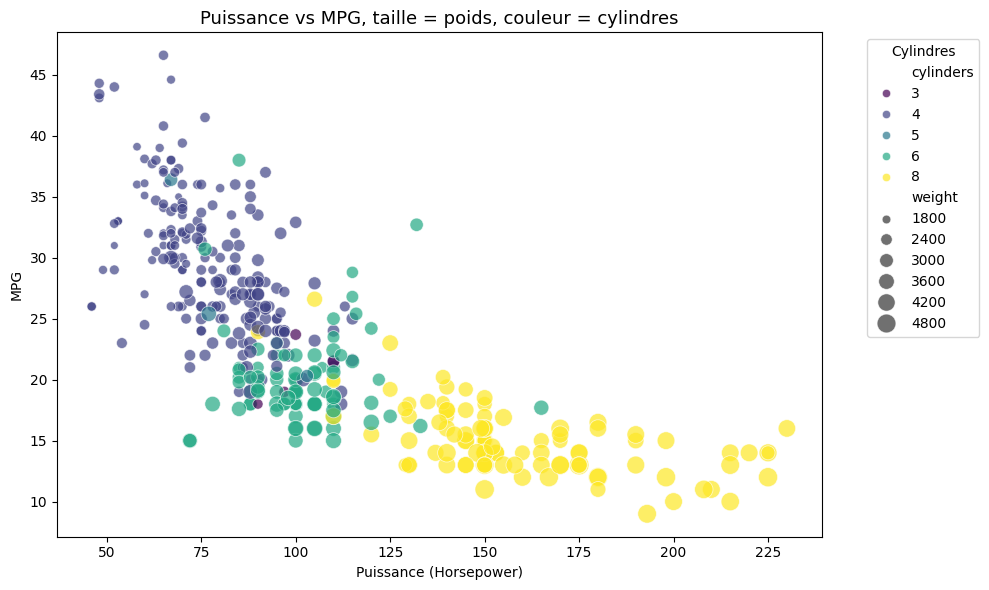

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mpg_df, x='horsepower', y='mpg', hue='cylinders', palette='viridis', size='weight', sizes=(30, 200), alpha=0.7)
plt.title('Puissance vs MPG, taille = poids, couleur = cylindres', fontsize=13)
plt.xlabel('Puissance (Horsepower)')
plt.ylabel('MPG')
plt.legend(title='Cylindres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Line Plot : Évolution de la consommation moyenne par année

Ce graphique montre comment la consommation moyenne (MPG) a évolué au fil des années de production, séparée par pays d'origine.

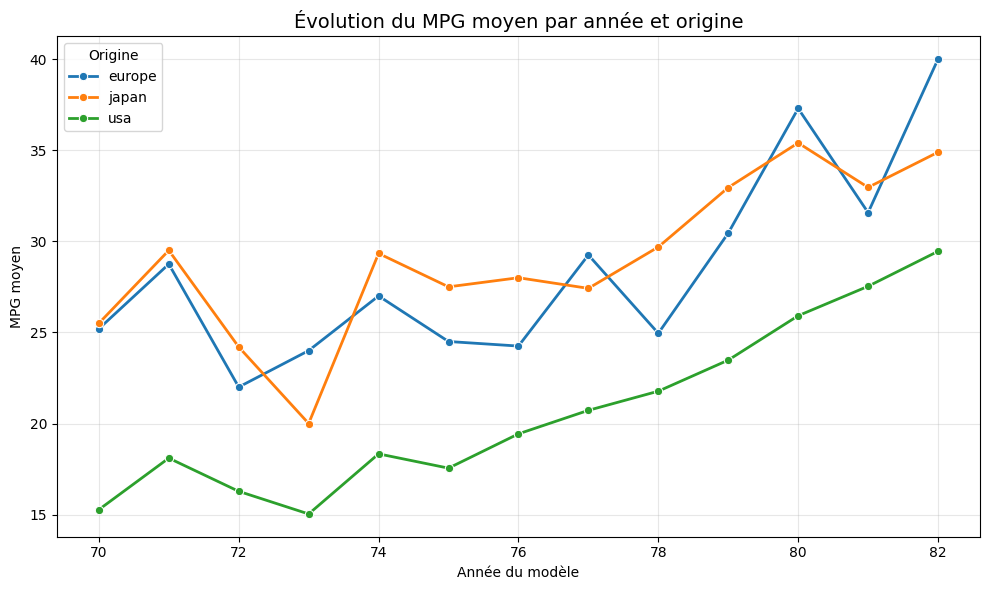

In [17]:
mpg_by_year_origin = mpg_df.groupby(['model_year', 'origin'])['mpg'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=mpg_by_year_origin, x='model_year', y='mpg', hue='origin', marker='o', linewidth=2)
plt.title('Évolution du MPG moyen par année et origine', fontsize=14)
plt.xlabel('Année du modèle')
plt.ylabel('MPG moyen')
plt.legend(title='Origine')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Line Plot : Évolution du poids moyen des véhicules par année

On observe ici la tendance du poids moyen des voitures au fil du temps, par origine géographique.

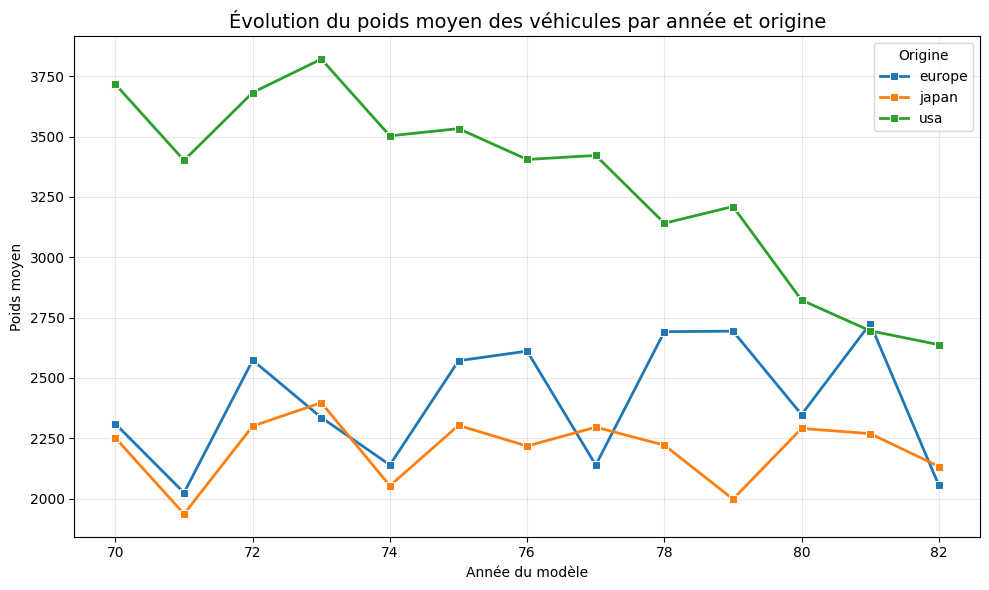

In [18]:
weight_by_year = mpg_df.groupby(['model_year', 'origin'])['weight'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=weight_by_year, x='model_year', y='weight', hue='origin', marker='s', linewidth=2)
plt.title('Évolution du poids moyen des véhicules par année et origine', fontsize=14)
plt.xlabel('Année du modèle')
plt.ylabel('Poids moyen')
plt.legend(title='Origine')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Heatmap : Matrice de corrélation des variables numériques

La heatmap des corrélations permet d'identifier rapidement quelles variables sont fortement liées entre elles (positivement ou négativement).

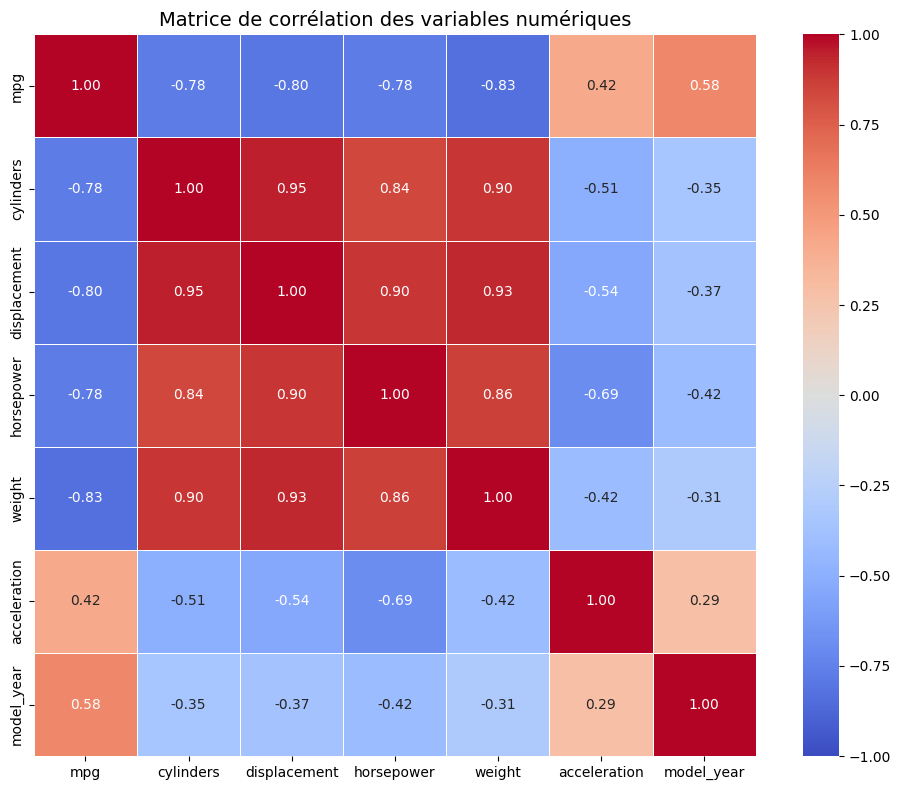

In [19]:
numeric_cols = mpg_df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Heatmap : Consommation moyenne par nombre de cylindres et origine

Cette heatmap croisée montre la consommation moyenne (MPG) pour chaque combinaison de cylindres et d'origine géographique.

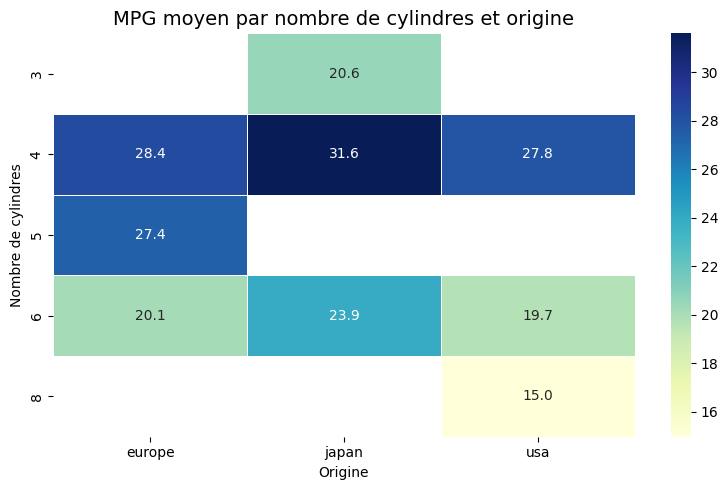

In [20]:
pivot_table = mpg_df.pivot_table(values='mpg', index='cylinders', columns='origin', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('MPG moyen par nombre de cylindres et origine', fontsize=14)
plt.xlabel('Origine')
plt.ylabel('Nombre de cylindres')
plt.tight_layout()
plt.show()

## 7. Pair Plot : Relations entre toutes les variables continues

Le pair plot permet de visualiser d'un coup d'œil toutes les relations deux à deux entre les variables numériques, colorées par origine.

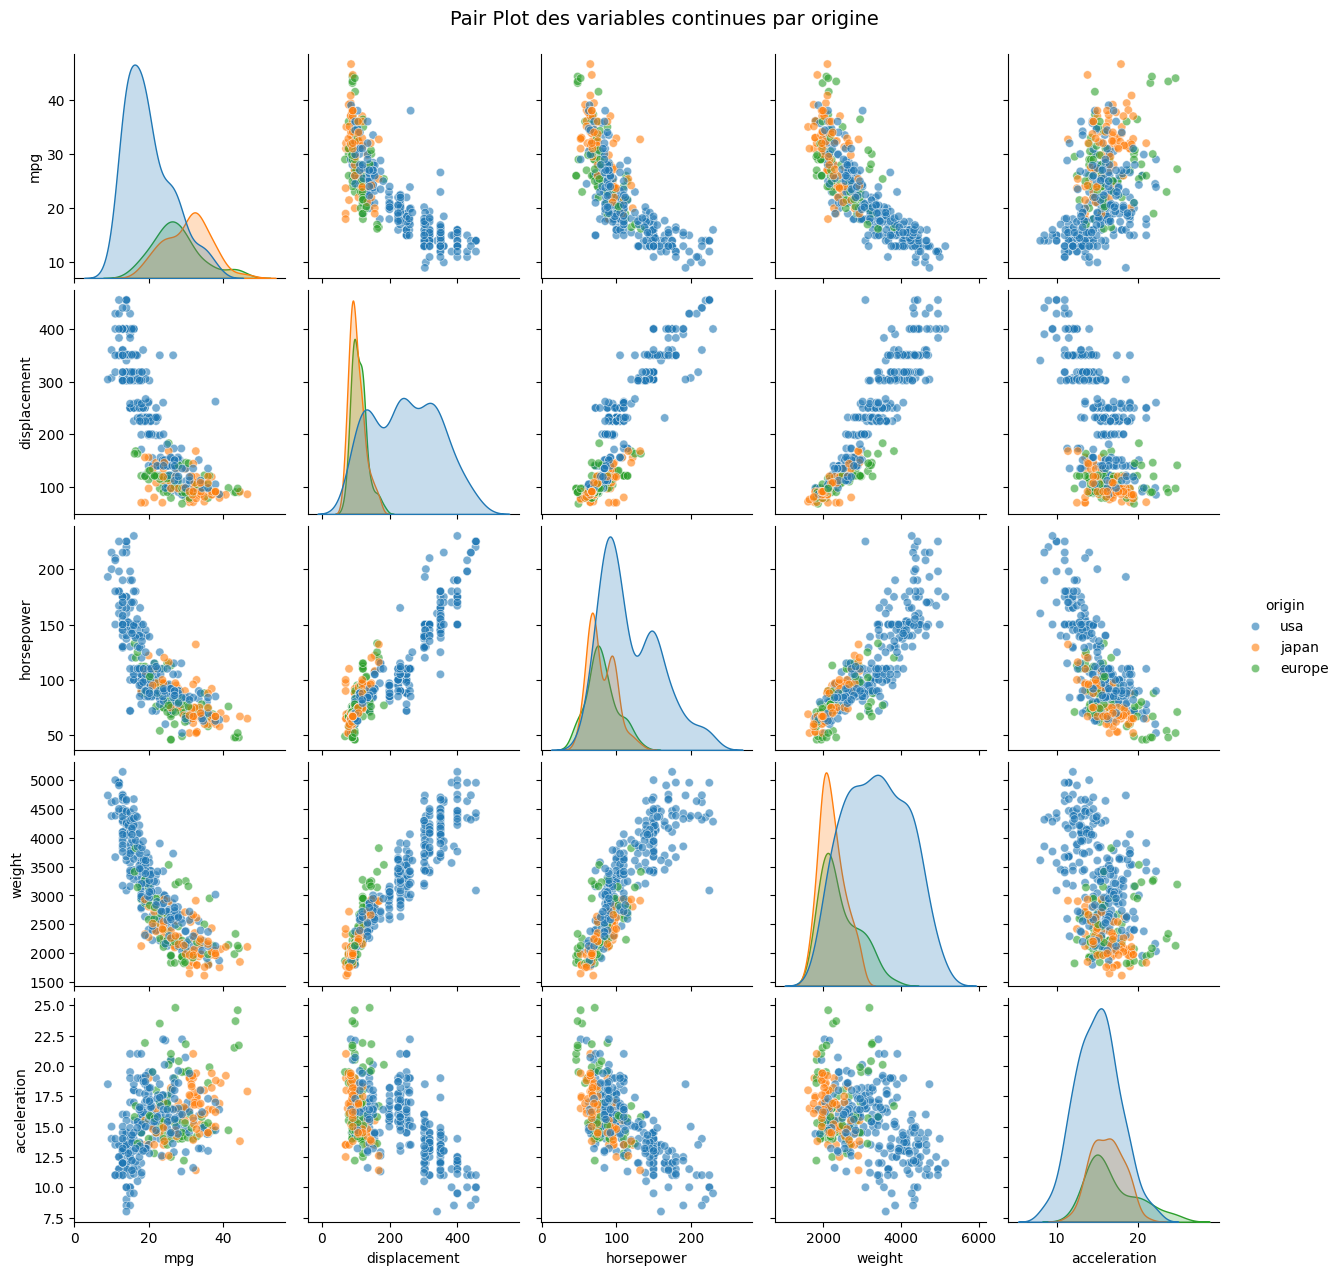

In [21]:
sns.pairplot(mpg_df[['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'origin']].dropna(),
             hue='origin', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot des variables continues par origine', y=1.02, fontsize=14)
plt.show()

## 8. Hexbin Plot : Densité Poids vs Consommation (MPG)

Le hexbin plot est une alternative au scatter plot pour les données denses. Il agrège les points dans des hexagones dont la couleur indique la densité, ce qui permet de mieux repérer les zones de concentration.

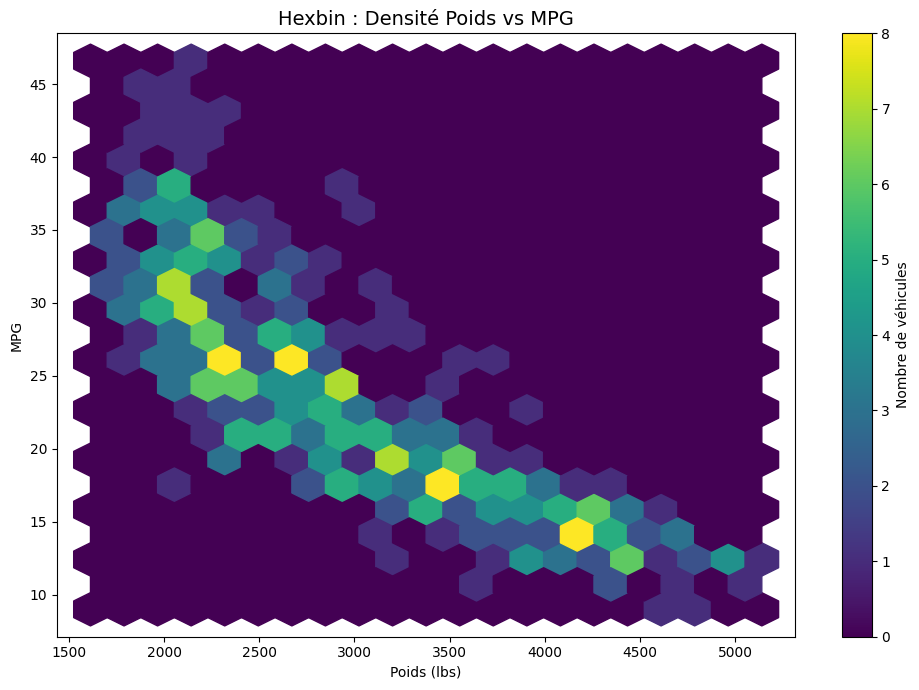

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(mpg_df['weight'], mpg_df['mpg'], gridsize=20)
cb = fig.colorbar(hb, ax=ax, label='Nombre de véhicules')
ax.set_title('Hexbin : Densité Poids vs MPG', fontsize=14)
ax.set_xlabel('Poids (lbs)')
ax.set_ylabel('MPG')
plt.tight_layout()
plt.show()